<div align="center">
  <h1>KNN Classification Project</h1>
  <h1>Red Wine Quality</h1>
  <p><strong>Author:</strong> Venkata Timmaraju</p>
</div>

This notebook builds a K-Nearest Neighbors (KNN) classifier to group red wines into quality categories based on physicochemical measurements.

****

## 1. Load the Dataset and Create Target Classes

**Dataset:** UCI Wine Quality (Red)

- Source: https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/
- File: `winequality-red.csv`
- Shape: 1,599 rows and 11 input features
- Original target column: `quality` (integer score)

The original `quality` score is converted into a 3-class target (`label`) for classification:

- `0` -> low quality (`quality <= 4`)
- `1` -> medium quality (`quality = 5 or 6`)
- `2` -> high quality (`quality >= 7`)

In [9]:
# Your code here
import pandas as pd

df = pd.read_csv(
    "https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-red.csv",
    sep=";",
)

# Group original wine quality into 3 classes:
# 0 -> quality <= 4, 1 -> quality 5 to 6, 2 -> quality >= 7
# bins are right-inclusive by default in pd.cut, so 4 goes to class 0 and 6 goes to class 1.
df["label"] = pd.cut(
    df["quality"],
    bins=[-float("inf"), 4, 6, float("inf")],
    labels=[0, 1, 2],
).astype("int8")

print(df[["quality", "label"]].head())

   quality  label
0        5      1
1        5      1
2        5      1
3        6      1
4        5      1


## 2. Prepare Features and Train/Test Split

- Define predictors (`X`) and target (`y`).
- Remove `quality` and `label` from predictors to avoid target leakage.
- Split the data into training and test sets (80/20).
- Use stratification so class proportions remain similar in both sets.

In [10]:
from sklearn.model_selection import train_test_split

# Use only predictor columns. Exclude quality and label to avoid target leakage.
X = df.drop(columns=["quality", "label"])

# Train the model to predict the grouped target.
y = df["label"]

# Stratify keeps class proportions similar in train and test sets.
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

## 3. Train a Baseline KNN Model

- Standardize features using `StandardScaler` because KNN is distance-based.
- Train a baseline model with `k = 11`.
- Evaluate baseline performance using test accuracy.

In [11]:
from sklearn.metrics import accuracy_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler

# Scale features before KNN because distance-based models are sensitive to feature magnitudes.
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

k = 11
knn = KNeighborsClassifier(n_neighbors=k)
knn.fit(X_train_scaled, y_train)

y_pred = knn.predict(X_test_scaled)
accuracy_score(y_test, y_pred)

0.859375

## 4. Evaluate with a Confusion Matrix

- Compute the confusion matrix for classes `0`, `1`, and `2`.
- Visualize class-wise correct predictions and misclassifications.

[[  0  13   0]
 [  0 250  14]
 [  0  18  25]]


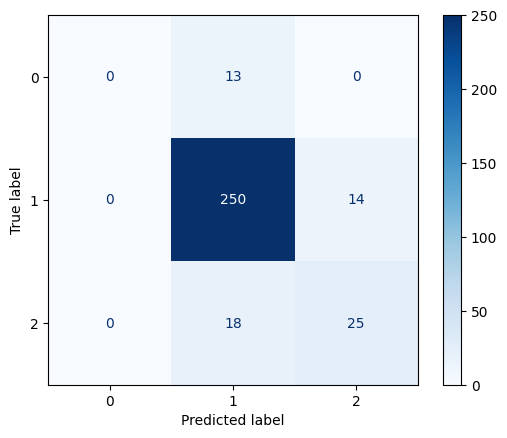

In [12]:
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

cm = confusion_matrix(y_test, y_pred, labels=[0, 1, 2])
print(cm)

ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0, 1, 2]).plot(cmap="Blues")

## 5. Evaluate with a Classification Report

- Report precision, recall, and F1-score for each class.
- Use these metrics to complement overall accuracy.

In [13]:
import warnings

from sklearn.metrics import classification_report

warnings.filterwarnings("ignore")

print(classification_report(y_test, y_pred, labels=[0, 1, 2]))

              precision    recall  f1-score   support

           0       0.00      0.00      0.00        13
           1       0.89      0.95      0.92       264
           2       0.64      0.58      0.61        43

    accuracy                           0.86       320
   macro avg       0.51      0.51      0.51       320
weighted avg       0.82      0.86      0.84       320



## 6. Tune `k` with a Parameter Sweep

- Train KNN models for `k = 1` to `30` using the same train/test split.
- Record test accuracy for each candidate.
- Select the `k` value with the highest observed test accuracy.

Note: this is a simple hold-out tuning approach, not cross-validation.

In [14]:
from sklearn.pipeline import make_pipeline

results_list = []
for k_candidate in range(1, 31):
    model_k = make_pipeline(
        StandardScaler(),
        KNeighborsClassifier(n_neighbors=k_candidate)
    )
    model_k.fit(X_train, y_train)
    y_pred_k = model_k.predict(X_test)

    # Save each result as a dictionary in a list.
    results_list.append(
        {
            "k": k_candidate,
            "accuracy": accuracy_score(y_test, y_pred_k),
        }
    )

k_scores = pd.DataFrame(results_list).sort_values(by="accuracy", ascending=False)

best_k = int(k_scores.iloc[0]["k"])
best_accuracy = float(k_scores.iloc[0]["accuracy"])
print(f"Best k: {best_k} | Accuracy: {best_accuracy:.4f}")
print(k_scores.head(10))

# Optional: preview raw list data
print(results_list[:5])

Best k: 11 | Accuracy: 0.8594
     k  accuracy
10  11  0.859375
11  12  0.859375
28  29  0.853125
27  28  0.850000
29  30  0.850000
9   10  0.846875
13  14  0.843750
6    7  0.843750
26  27  0.843750
23  24  0.843750
[{'k': 1, 'accuracy': 0.81875}, {'k': 2, 'accuracy': 0.815625}, {'k': 3, 'accuracy': 0.828125}, {'k': 4, 'accuracy': 0.828125}, {'k': 5, 'accuracy': 0.81875}]


## 7. Visualize Accuracy vs. `k`

- Plot accuracy for each `k` value.
- Highlight the best-performing `k` for quick interpretation.

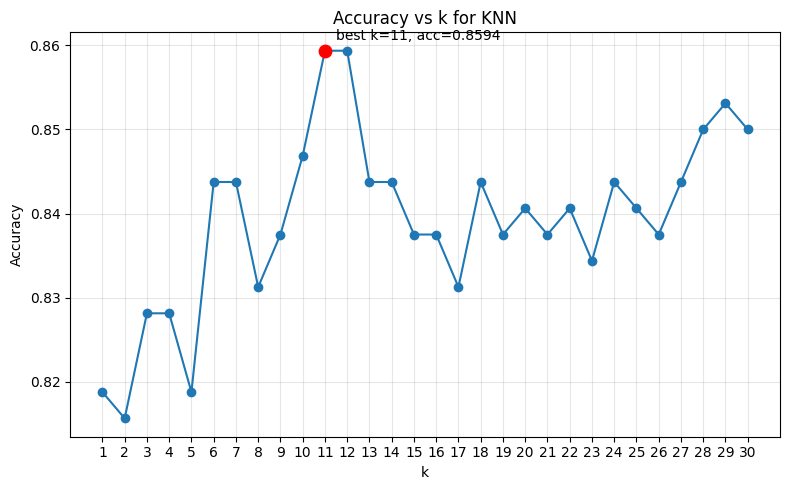

In [15]:
import matplotlib.pyplot as plt

plot_df = pd.DataFrame(results_list).sort_values(by="k")

plt.figure(figsize=(8, 5))
plt.plot(plot_df["k"], plot_df["accuracy"], marker="o", linewidth=1.5)

best_row = plot_df.loc[plot_df["accuracy"].idxmax()]
plt.scatter(best_row["k"], best_row["accuracy"], color="red", s=80, zorder=3)
plt.annotate(
    f"best k={int(best_row['k'])}, acc={best_row['accuracy']:.4f}",
    (best_row["k"], best_row["accuracy"]),
    textcoords="offset points",
    xytext=(8, 8),
)

plt.title("Accuracy vs k for KNN")
plt.xlabel("k")
plt.ylabel("Accuracy")
plt.xticks(plot_df["k"])
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 8. Predict a New Wine Sample

- Define a helper function that accepts the 11 feature values.
- Build a one-row input DataFrame with the same feature order as training data.
- Use the fitted scaler and baseline KNN model to predict the class label.
- Return both the numeric class (`0/1/2`) and readable class name (`low/medium/high`).

In [16]:
feature_columns = X.columns.tolist()

def predict_quality(
    fixed_acidity,
    volatile_acidity,
    citric_acid,
    residual_sugar,
    chlorides,
    free_sulfur_dioxide,
    total_sulfur_dioxide,
    density,
    pH,
    sulphates,
    alcohol,
):
    input_data = pd.DataFrame(
        [
            {
                "fixed acidity": fixed_acidity,
                "volatile acidity": volatile_acidity,
                "citric acid": citric_acid,
                "residual sugar": residual_sugar,
                "chlorides": chlorides,
                "free sulfur dioxide": free_sulfur_dioxide,
                "total sulfur dioxide": total_sulfur_dioxide,
                "density": density,
                "pH": pH,
                "sulphates": sulphates,
                "alcohol": alcohol,
            }
        ],
        columns=feature_columns,
    )

    pred_label = int(knn.predict(scaler.transform(input_data))[0])
    label_map = {0: "low", 1: "medium", 2: "high"}
    return {"label": pred_label, "quality_group": label_map[pred_label]}

# Example prediction
predict_quality(7.4, 0.70, 0.00, 1.9, 0.076, 11, 34, 0.9978, 3.51, 0.56, 9.4)

{'label': 1, 'quality_group': 'medium'}

## 9. Final Conclusion

Trying different `k` values and reviewing the evaluation metrics made it clear that KNN can classify wine quality into low, medium, and high categories with reasonable consistency.

One key takeaway is that feature scaling is very important here, because KNN decisions are based on distance between points.

For the example tested at the end, the model predicts **medium** quality (`label = 1`).